In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import scipy
import plotly.express as px
from scipy.stats import ranksums

In [3]:
COLOR_PENK = (0, 0, 1, 1)
COLOR_NONPENK = (1, 0, 0, 1)

LINEWIDTH_HIST = 3

In [4]:
cfg = M2PConfig()

# Load good data only
df_exps, df_roi, df_ca = db.get_roi_ca_data(cfg)

Excluded 26221 bad 2p frames 0.54%


In [5]:
np.sum(df_roi['celltype']=='nonpenk')

46

RanksumsResult(statistic=-2.460213805143862, pvalue=0.013885426810540771)
RanksumsResult(statistic=-3.028933835431918, pvalue=0.002454184254573418)


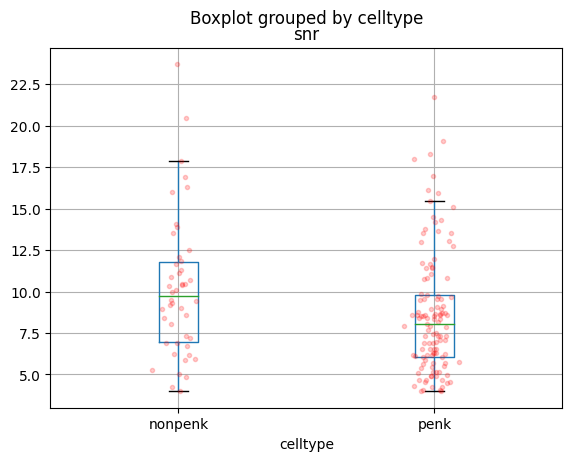

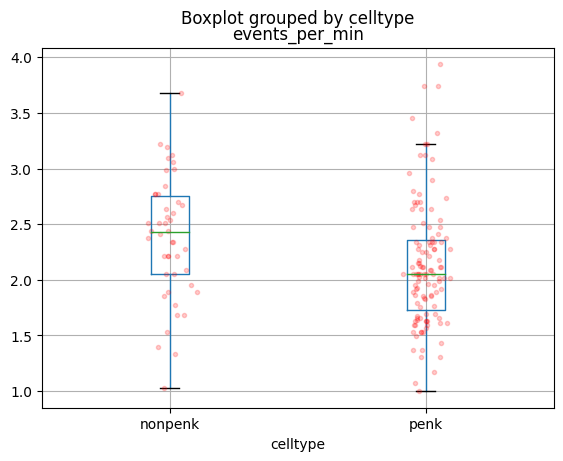

In [6]:


#df_roi.boxplot(column='snr', by='celltype')
fig, ax = plt.subplots()
df_roi_sorttype = df_roi.sort_values(by='celltype', ascending=True)
df_roi_sorttype.boxplot(column='snr', by='celltype', ax=ax, showfliers=False)
for i, group in enumerate(df_roi_sorttype['celltype'].unique()):
    y = df_roi[df_roi['celltype']==group]['snr']
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.plot(x, y, 'r.', alpha=0.2)
#df_roi.boxplot(column='events_per_min', by='celltype')
fig, ax = plt.subplots()
df_roi_sorttype.boxplot(column='events_per_min', by='celltype', ax=ax, showfliers=False)
for i, group in enumerate(df_roi_sorttype['celltype'].unique()):
    y = df_roi[df_roi['celltype']==group]['events_per_min']
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.plot(x, y, 'r.', alpha=0.2)

groups = df_roi.groupby('celltype')['snr']
result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
print(result)

groups = df_roi.groupby('celltype')['events_per_min']
result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
print(result)

134 165


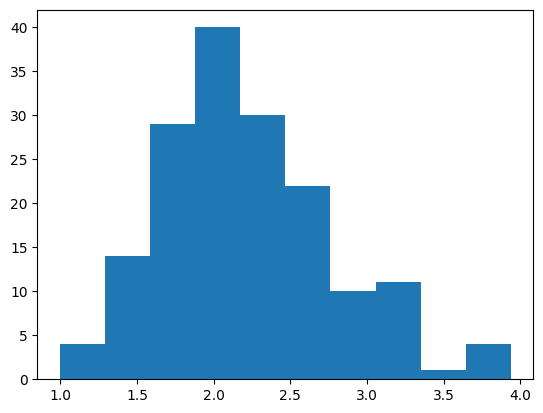

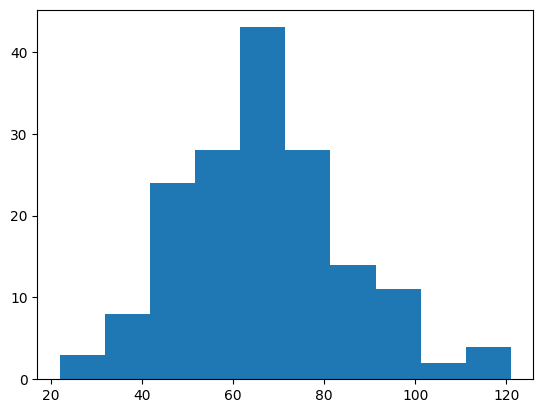

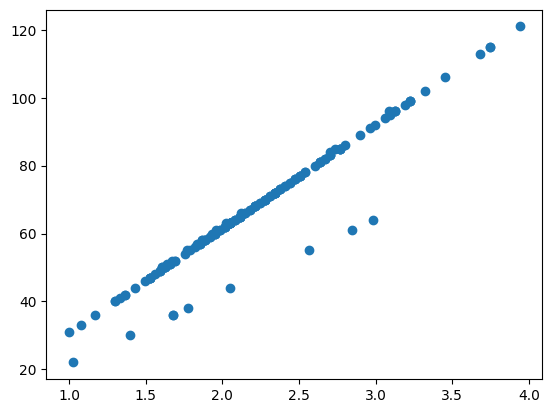

In [7]:
plt.hist(df_roi["events_per_min"])
plt.figure()
plt.hist(df_roi["n_events"])
plt.figure()
plt.scatter(df_roi["events_per_min"], df_roi["n_events"])
print(np.sum(df_roi["n_events"] > 50), df_roi.shape[0])

Text(0, 0.5, 'SNR')

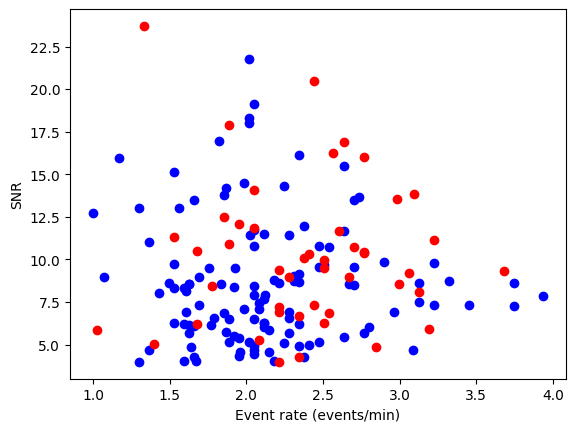

In [8]:
penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

plt.figure()
plt.scatter(df_roi.loc[penk_indexes]['events_per_min'],
            df_roi.loc[penk_indexes]['snr'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_roi.loc[nonpenk_indexes]['events_per_min'],
            df_roi.loc[nonpenk_indexes]['snr'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Event rate (events/min)")
plt.ylabel("SNR")

Text(0, 0.5, 'Std non events (dF/F0)')

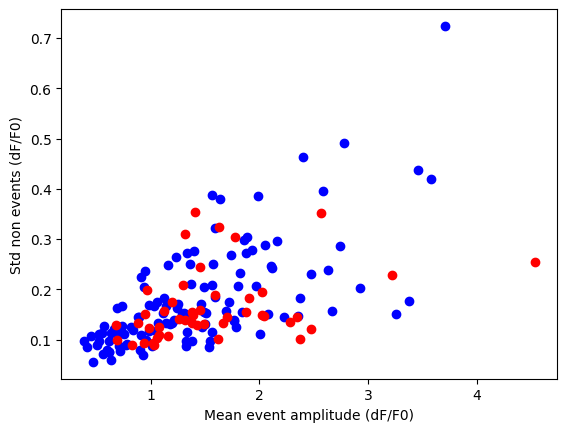

In [9]:

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

plt.figure()
plt.scatter(df_roi.loc[penk_indexes]['mean_event_dFonF0_amp'],
            df_roi.loc[penk_indexes]['std_nonevent_dFonF0'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_roi.loc[nonpenk_indexes]['mean_event_dFonF0_amp'],
            df_roi.loc[nonpenk_indexes]['std_nonevent_dFonF0'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Mean event amplitude (dF/F0)")
plt.ylabel("Std non events (dF/F0)")

In [10]:
resp_col = "deconv_norm"
df_metric = df_ca.pivot_table(index=['exp_id', 'roi_id', 'celltype'], 
                              values=[resp_col], aggfunc=['mean', 'var', 'count']).reset_index()

/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_75772/320036260.py:6: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  df_merge = df_metric.merge(df_roi, on=['exp_id', 'roi_id'], how='inner')


Text(0, 0.5, 'Mean events amplitude (df/F0)')

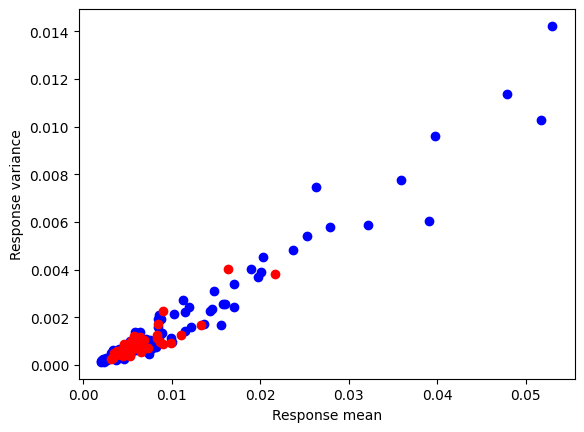

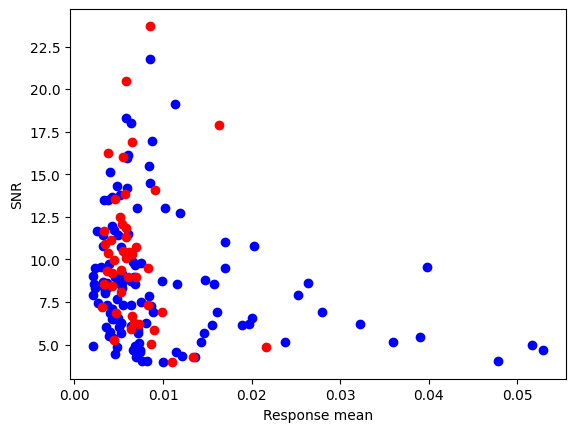

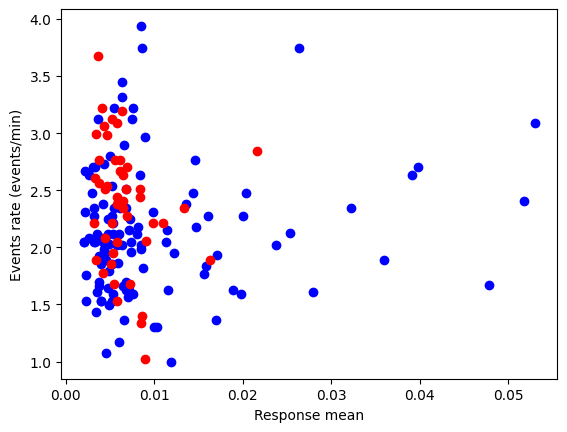

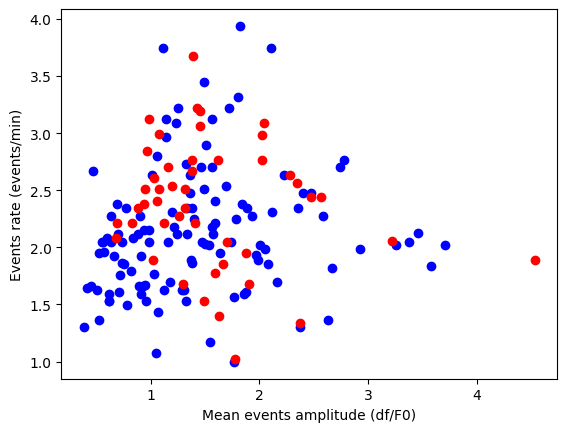

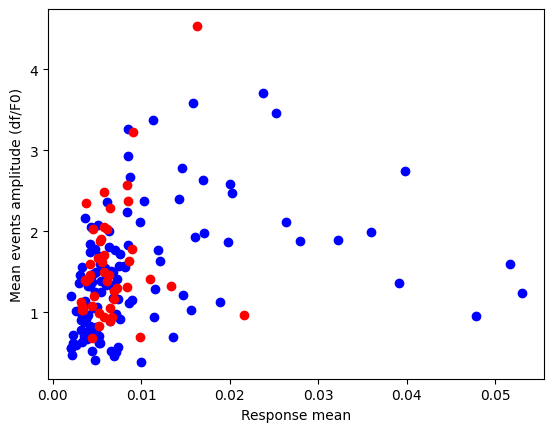

In [11]:
df_metric[('mean', resp_col)]

penk_indexes = df_metric["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

df_merge = df_metric.merge(df_roi, on=['exp_id', 'roi_id'], how='inner')

plt.figure()
plt.scatter(df_merge.loc[penk_indexes][('mean', resp_col)],
            df_merge.loc[penk_indexes][('var', resp_col)],
            color=COLOR_PENK, label="penk")
plt.scatter(df_merge.loc[nonpenk_indexes][('mean', resp_col)],
            df_merge.loc[nonpenk_indexes][('var', resp_col)],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Response mean")
plt.ylabel("Response variance")

plt.figure()
plt.scatter(df_merge.loc[penk_indexes][('mean', resp_col)],
            df_merge.loc[penk_indexes]['snr'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_merge.loc[nonpenk_indexes][('mean', resp_col)],
            df_merge.loc[nonpenk_indexes]['snr'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Response mean")
plt.ylabel("SNR")

plt.figure()
plt.scatter(df_merge.loc[penk_indexes][('mean', resp_col)],
            df_merge.loc[penk_indexes]['events_per_min'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_merge.loc[nonpenk_indexes][('mean', resp_col)],
            df_merge.loc[nonpenk_indexes]['events_per_min'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Response mean")
plt.ylabel("Events rate (events/min)")

plt.figure()
plt.scatter(df_merge.loc[penk_indexes]['mean_event_dFonF0_amp'],
            df_merge.loc[penk_indexes]['events_per_min'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_merge.loc[nonpenk_indexes]['mean_event_dFonF0_amp'],
            df_merge.loc[nonpenk_indexes]['events_per_min'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Mean events amplitude (df/F0)")
plt.ylabel("Events rate (events/min)")

plt.figure()
plt.scatter(df_merge.loc[penk_indexes][('mean', resp_col)],
            df_merge.loc[penk_indexes]['mean_event_dFonF0_amp'],
            color=COLOR_PENK, label="penk")
plt.scatter(df_merge.loc[nonpenk_indexes][('mean', resp_col)],
            df_merge.loc[nonpenk_indexes]['mean_event_dFonF0_amp'],
            color=COLOR_NONPENK, label="nonpenk")

plt.xlabel("Response mean")
plt.ylabel("Mean events amplitude (df/F0)")







In [12]:
df_merge['mean_event_dFonF0_amp']

0      3.460688
1      1.878410
2      2.744010
3      1.767460
4      1.500829
         ...   
160    1.929163
161    1.803636
162    1.112606
163    1.826289
164    0.939930
Name: mean_event_dFonF0_amp, Length: 165, dtype: float64

In [13]:

df_metric.groupby('exp_id').count()


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_75772/3927590461.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_metric.groupby('exp_id').count()


,roi_id,celltype,mean,var,count
,,,deconv_norm,deconv_norm,deconv_norm
exp_id,,,,,
20210823_16_59_50_1114353,16,16,16,16,16
20211028_11_25_50_1115465,22,22,22,22,22
20211203_15_10_27_1115464,27,27,27,27,27
20220408_15_01_57_1116663,17,17,17,17,17
20220608_15_27_32_1117217,2,2,2,2,2
20220608_16_22_06_1116994,12,12,12,12,12
20220802_15_06_53_1117646,11,11,11,11,11
20221003_14_36_54_1118020,11,11,11,11,11


In [14]:
grp_df_cell = df_ca.groupby(['exp_id', 'animal_id', 'roi_id', 'celltype', 'roi_type'])

RanksumsResult(statistic=1.0120672743464778, pvalue=0.3115058883382391)


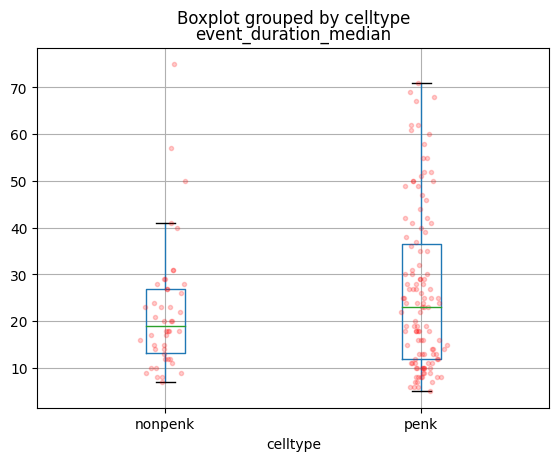

In [15]:
n_pre_frames = 10
n_post_frames = 10
event_durations = []
penk_durations = []
nonpenk_durations = []
df_roi_events = db.get_roi_events_df()
df_roi_fresh = pd.read_hdf(cfg.db_ca_roi_file, key='key')
for (exp_id, animal_id, roi_id, cell_type, roi_type), df_group in grp_df_cell:
    event_start_indexes = df_group[cu.CA_EVENTS_ONSET] == 1

    event_starts = np.where(event_start_indexes)[0]
    #plt.figure()
    for i_event_start in event_starts:
        # find the next CA_EVENTS_OFFSET 
        #print(i_event_start, df_group.shape)
        i_event_end = i_event_start + np.where(df_group[i_event_start:][cu.CA_EVENTS_MASK]==0)[0][0]
        
        roi_fresh_index = (df_roi_fresh['exp_id'] == exp_id) & \
                    (df_roi_fresh['roi_id'] == roi_id) & \
                    (df_roi_fresh['roi_type'] == roi_type)
        
        roi_index = (df_roi['exp_id'] == exp_id) & \
                    (df_roi['roi_id'] == roi_id) & \
                    (df_roi['roi_type'] == roi_type)
        
        #plt.plot(df_group[i_event_start-n_pre_frames: i_event_end+n_post_frames][cu.CA_DFONF0_CLEAN].values, color='gray')
        
        event_duration = i_event_end - i_event_start
        event_durations.append(event_duration)
     
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_mean'] = np.mean(event_duration)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_std'] = np.std(event_duration)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_median'] = np.median(event_duration)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_min'] = np.min(event_duration)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_max'] = np.max(event_duration)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_p5'] = np.percentile(event_duration, 5)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_p95'] = np.percentile(event_duration, 95)
    df_roi_fresh.loc[roi_fresh_index, 'event_duration_p5_p95'] = np.percentile(event_duration, 95) - np.percentile(event_duration, 5)
    
    df_roi.loc[roi_index, 'event_duration_mean'] = np.mean(event_duration)
    df_roi.loc[roi_index, 'event_duration_std'] = np.std(event_duration)
    df_roi.loc[roi_index, 'event_duration_median'] = np.median(event_duration)
    df_roi.loc[roi_index, 'event_duration_min'] = np.min(event_duration)
    df_roi.loc[roi_index, 'event_duration_max'] = np.max(event_duration)
    df_roi.loc[roi_index, 'event_duration_p5'] = np.percentile(event_duration, 5)
    df_roi.loc[roi_index, 'event_duration_p95'] = np.percentile(event_duration, 95)
    df_roi.loc[roi_index, 'event_duration_p5_p95'] = np.percentile(event_duration, 95) - np.percentile(event_duration, 5)

metric = 'event_duration_median'
fig, ax = plt.subplots()
df_roi_sorttype = df_roi.sort_values(by='celltype', ascending=True)
df_roi_sorttype.boxplot(column=metric, by='celltype', ax=ax, showfliers=False)
for i, group in enumerate(df_roi_sorttype['celltype'].unique()):
    y = df_roi[df_roi['celltype']==group][metric]
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.plot(x, y, 'r.', alpha=0.2)


groups = df_roi.groupby('celltype')[metric]
result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
print(result)


    
    

In [16]:
# Save back to disk
#df_roi_fresh.to_hdf(str(cfg.db_ca_roi_file), key="key", mode='w')
